### Remove the beams 10 and 11

In [1]:
import torch
import numpy as np
import random
import os

def set_seed(seed: int = 42) -> None:
    """
    Sets the random seed for reproducibility across multiple libraries.
    """
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed) # For multi-GPU models
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    print(f"Random seed set as {seed}")

# Usage:
set_seed(70)

Random seed set as 70


In [1]:
model = torch.load('nets/consis/250_350r/first.pt', weights_only=False)
mask = model['masker']

NameError: name 'torch' is not defined

In [1]:
import torch
import Modules.preprocess as pp
import numpy as np 

data  = torch.load('../../data/data.pt', weights_only=True)
frames = np.arange(300, 320, 1)
beams = list(range(0,32))
w_0 =1

datasets = pp.data_gen(data =data, beams = beams, frames = frames, normalize='SS',splits = .8, w_0=w_0)
train_dataloader, ver_dataloader = datasets.get_dataloaders(num_workers =4, batch_size = 1)

In [5]:
import Modules.trainers as tr
import torch
from Modules.Neural_Net import Net, Sine

act = torch.nn.Tanh()
num_epochs = 200
model_config = (3, 300, 500, 500, 300)

net = Net(act, *model_config, w_0 = w_0, siren= False).to('cuda')
optimizer = torch.optim.Adam(net.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer=optimizer, T_max = num_epochs)

In [7]:
'Start training'
path = 'nets/cat_vid/tanh.pt'


trainer =  tr.training(device='cuda', dataloader= train_dataloader, model_config=model_config,
                        optimizer=optimizer, net=net, scalers=datasets.get_scalers(), masker=datasets.get_mask(), w_0 = w_0, act =act )

train = trainer.MSE_training(num_epochs, prints=True, saving=True, 
                                save_path=path, count = 100)


Epoch 0, Batch 0, Loss: 2.343615
Epoch 0 Complete - Avg Loss: 3.118730
New best loss: 3.118730 at epoch 0
Epoch 1, Batch 0, Loss: 2.257875
Epoch 1 Complete - Avg Loss: 2.021370
New best loss: 2.021370 at epoch 1
Epoch 2, Batch 0, Loss: 1.619441
Epoch 2 Complete - Avg Loss: 1.044289
New best loss: 1.044289 at epoch 2
Epoch 3, Batch 0, Loss: 0.494137
Epoch 3 Complete - Avg Loss: 0.414044
New best loss: 0.414044 at epoch 3
Epoch 4, Batch 0, Loss: 0.612185
Epoch 4 Complete - Avg Loss: 0.223804
New best loss: 0.223804 at epoch 4
Epoch 5, Batch 0, Loss: 0.131094
Epoch 5 Complete - Avg Loss: 0.310675
Epoch 6, Batch 0, Loss: 0.738012
Epoch 6 Complete - Avg Loss: 0.282336
Epoch 7, Batch 0, Loss: 0.145170
Epoch 7 Complete - Avg Loss: 0.218734
New best loss: 0.218734 at epoch 7
Epoch 8, Batch 0, Loss: 0.113722
Epoch 8 Complete - Avg Loss: 0.200208
New best loss: 0.200208 at epoch 8
Epoch 9, Batch 0, Loss: 0.183176
Epoch 9 Complete - Avg Loss: 0.186789
New best loss: 0.186789 at epoch 9
Epoch 10, 

### Train over all the frames

In [6]:
import Modules.preprocess as pp
import numpy as np 
import torch 
import Modules.trainers as tr
from Modules.Neural_Net import Net, Sine


data  = torch.load('../../data/data.pt', weights_only=True)
num_epochs = 200
model_config = (3, 300, 500, 500, 300)
beams = list(range(0,32))
w_0 =1

act = Sine(w_0)
stride, step, start, end = [100, 2,0, 3500]
save = "nets/complete/"

current = start
while current <end:
    current += stride
    frames = np.arange(current - stride, current, step)
    
    datasets = pp.data_gen(data =data, beams = beams, frames = frames, normalize='SS',splits = .8, w_0=w_0)
    train_dataloader, ver_dataloader = datasets.get_dataloaders(num_workers =4, batch_size = 1)

    net = Net(act, *model_config, w_0 = w_0, siren= False).to('cuda')
    optimizer = torch.optim.Adam(net.parameters(), lr=1e-3)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer=optimizer, T_max = num_epochs)

    path = f'{current-stride:04d}_{current:04d}.pt'
    save_path = save + path


    trainer =  tr.training(device='cuda', dataloader= train_dataloader, model_config=model_config,
                            optimizer=optimizer, net=net, scalers=datasets.get_scalers(), masker=datasets.get_mask(), w_0 = w_0, act =act )

    train = trainer.MSE_training(num_epochs, prints=True, saving=True, 
                                    save_path=save_path, count = 100)



Epoch 0, Batch 0, Loss: 3.952173
Epoch 0 Complete - Avg Loss: 2.606585
New best loss: 2.606585 at epoch 0
Epoch 1, Batch 0, Loss: 2.744490
Epoch 1 Complete - Avg Loss: 1.487188
New best loss: 1.487188 at epoch 1
Epoch 2, Batch 0, Loss: 1.596420
Epoch 2 Complete - Avg Loss: 1.177446
New best loss: 1.177446 at epoch 2
Epoch 3, Batch 0, Loss: 0.240908
Epoch 3 Complete - Avg Loss: 0.685161
New best loss: 0.685161 at epoch 3
Epoch 4, Batch 0, Loss: 0.652640
Epoch 4 Complete - Avg Loss: 0.397382
New best loss: 0.397382 at epoch 4
Epoch 5, Batch 0, Loss: 0.372701
Epoch 5 Complete - Avg Loss: 0.782576
Epoch 6, Batch 0, Loss: 0.530587
Epoch 6 Complete - Avg Loss: 0.366544
New best loss: 0.366544 at epoch 6
Epoch 7, Batch 0, Loss: 0.183419
Epoch 7 Complete - Avg Loss: 0.299695
New best loss: 0.299695 at epoch 7
Epoch 8, Batch 0, Loss: 0.237310
Epoch 8 Complete - Avg Loss: 0.243550
New best loss: 0.243550 at epoch 8
Epoch 9, Batch 0, Loss: 0.141502
Epoch 9 Complete - Avg Loss: 0.244025
Epoch 10, 

In [7]:
net.to('cpu')

ins, outs = next(iter(train_dataloader))

z = net(ins)

In [8]:
x = ins.reshape(-1,3)[:,0].detach().numpy()
y = ins.reshape(-1,3)[:,1].detach().numpy()
z = z.reshape(-1,1).detach().numpy()

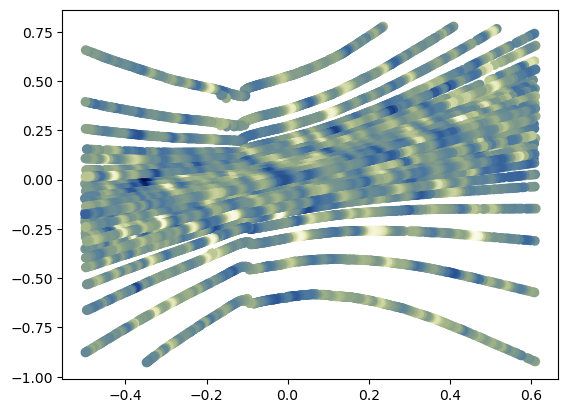

In [9]:
import matplotlib.pyplot as plt
import cmcrameri.cm as cmc

plt.scatter(x,y,c=z, cmap = cmc.davos)
plt.show()

tensor(0.0914, device='cuda:0') tensor(0.5415, device='cuda:0') tensor([[[ 1.4986,  0.7214,  0.2785],
         [ 1.4847,  0.7141,  0.2785],
         [ 1.4754,  0.7092,  0.2785],
         ...,
         [-1.1902, -0.4402,  0.2785],
         [-1.2063, -0.4454,  0.2785],
         [-1.2133, -0.4477,  0.2785]]], device='cuda:0')


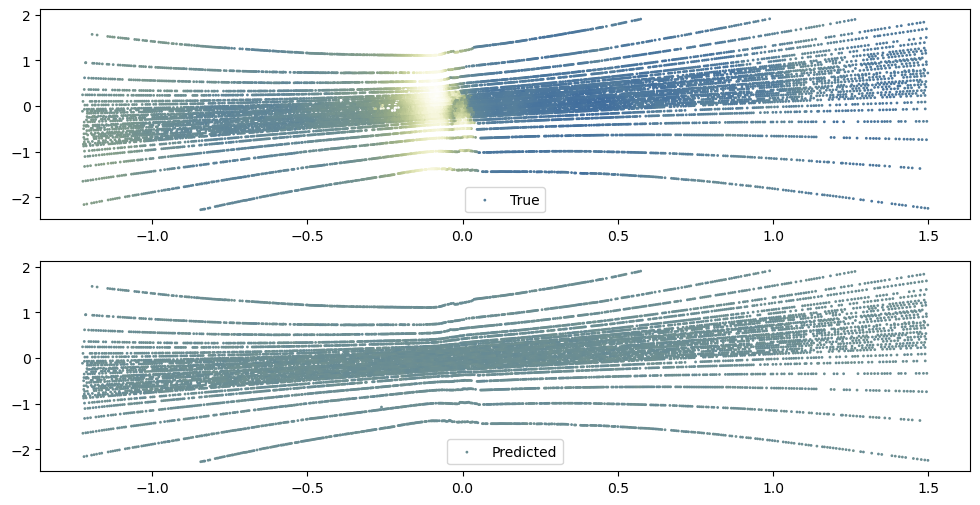

In [21]:
import matplotlib.pyplot as plt
import cmcrameri.cm as cmc

input_batch, output_batch = next(iter(train_dataloader))
input_batch = input_batch.to('cuda')

print(input_batch.mean(), input_batch.std(), input_batch)
with torch.no_grad():
    pred_batch = net(input_batch)

x = input_batch.cpu().numpy().reshape(-1, 3)[:,0]
y = input_batch.cpu().numpy().reshape(-1, 3)[:,1]



fig, (ax1, ax2 ) = plt.subplots(2,figsize=(12,6))


ax1.scatter(x, y, c= output_batch.cpu().numpy().flatten(), cmap = cmc.davos,  label='True', s=1, vmin= -2, vmax=2)

ax2.scatter(x, y, c= pred_batch.cpu().numpy().flatten(), cmap = cmc.davos,  label='Predicted',s=1, vmin= -2, vmax=2)
ax1.legend()
ax2.legend()
plt.show()



In [20]:
import torch
import numpy as np
from Modules.Neural_Net import Net
import Modules.preprocess as pp
import re
#This defines where the data is

network_data = 'nets/siren/freq_300_320.pt' 

data  = torch.load('../../data/data.pt', weights_only=True)
nums = re.findall(r'\d+', network_data)  
first, second = map(int, nums[:2]) 
frames = np.arange(first, second, step=1)


train_beams = list(range(0, 32))
#This generates the data
train_data = pp.data_gen(data, beams = train_beams, frames=frames, normalize='SS', splits =.99)
train_dataloader, q  = train_data.get_dataloaders(train_data, batch_size=1, num_workers=4)

#This makes the model



In [ ]:
net.weights()

In [28]:
from Modules.evaluate import Evaluator
from Modules.evaluate import pick_data

time = 30.2

def add_t(tensor, time):
    return torch.cat([tensor, torch.ones_like(tensor[:, 0]).unsqueeze(1)*time], dim=1).to(dtype=torch.float32)

inputs = torch.load('Modules/plotting_region.pt', weights_only = True)
inputs = add_t(inputs,time)


raw = pick_data(data=data, beams= train_beams, frames =frames)
raw_in, raw_out = raw.data_out_numpy(time)
print(raw_in.shape)
raw_x = raw_in[:,0]
raw_y = raw_in[:,1]
raw_z = raw_out

x = inputs[:, 0].reshape(-1, 1).detach().numpy()
y = inputs[:, 1].reshape(-1, 1).detach().numpy()

inputs = inputs.to('cpu')
net = net.to('cpu')

evaluator = Evaluator(net, scalers = train_data.get_scalers(), inputs=inputs)
pred_z = evaluator.net_eval()


(17611, 3)


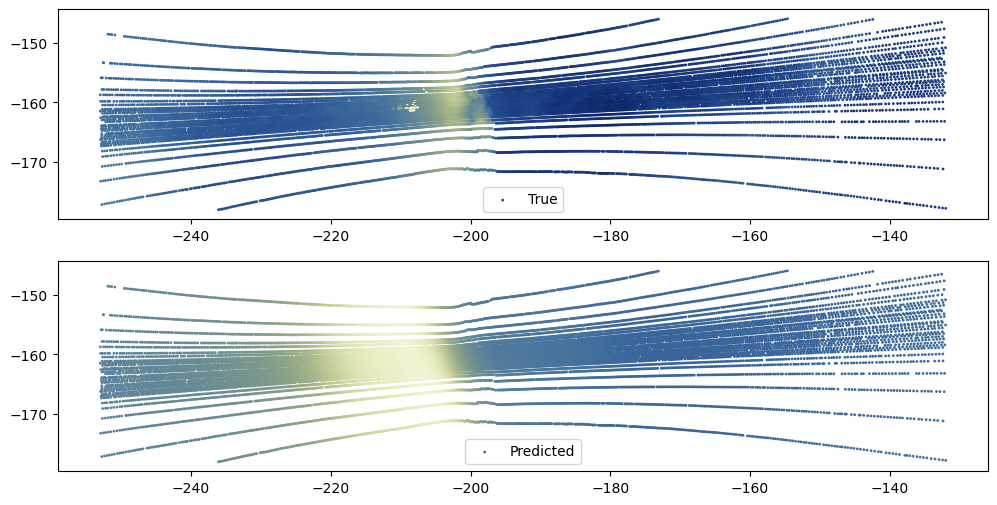

In [34]:
'scaled plotting'
t = 30.2

input_batch, output_batch = next(iter(train_dataloader))
input_batch = input_batch.to('cpu')
with torch.no_grad():
    pred_batch = net(input_batch)

input_scaler, output_scaler = train_data.get_scalers()

input_batch_unscaled = input_scaler.inverse_transform(input_batch.cpu().numpy().reshape(-1,3))
pred_batch_unscaled = output_scaler.inverse_transform(pred_batch.cpu().numpy().reshape(-1,1))
output_batch_unscaled = output_scaler.inverse_transform(output_batch.cpu().numpy().reshape(-1,1))
x = input_batch_unscaled[:,0]
y = input_batch_unscaled[:,1]
fig, (ax1, ax2 ) = plt.subplots(2,figsize=(12,6))

ax1.scatter(x, y, c= output_batch_unscaled, cmap = cmc.davos,  label='True', s=1, vmin = 0, vmax=6)
ax2.scatter(x, y, c= pred_batch_unscaled.flatten(), cmap = cmc.davos,  label='Predicted',s=1, vmin = -5, vmax=10)
ax1.legend()
ax2.legend()
plt.show()


# Old Work


In [4]:
import os
import multiprocessing
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'
os.environ['OMP_NUM_THREADS'] = '6'
os.environ['MKL_NUM_THREADS'] = '6'
os.environ['OPENBLAS_NUM_THREADS'] = '6'
os.environ['NUMEXPR_NUM_THREADS'] = '6'
os.environ['VECLIB_MAXIMUM_THREADS'] = '6'
os.environ['BLAS_NUM_THREADS'] = '6'

# Force multiprocessing to respect thread limits
multiprocessing.set_start_method('spawn', force=True)
from Modules import pre_pro
import torch
from torch.utils.data import TensorDataset, DataLoader
from Modules.Neural_Net import Net
from Modules.Losses import crit
import numpy as np
from Modules.beams import beam_trim
import matplotlib.pyplot as plt

In [3]:
data = torch.load('../../data/data.pt', weights_only=True)
frames = np.arange(250,350, 1)
device = 'cuda'

beams = list(range(0, 32))
indices_to_remove = [10, 11]
beams = [b for i, b in enumerate(beams) if i not in indices_to_remove]

with torch.no_grad():
    input, output = pre_pro.in_out(data, beams=beams, frames=frames)

dataloader = pre_pro.batching(input, output, workers=4)




NameError: name 'torch' is not defined

In [3]:
'Network set up'
network_info = torch.load('nets/MSE/MSE_250_350.pt', weights_only=True)

model_config = (3, 528 ,1024 , 1024, 528, 528)
net = Net(torch.cos, *model_config).to(device)
# net.load_state_dict(network_info['model_state_dict'])
optimizer = torch.optim.Adam(net.parameters(), lr=1e-4)
# optimizer.load_state_dict(network_info['optimizer_state_dict'])
# for param_group in optimizer.param_groups:
#     param_group['lr'] = 1e-4


In [ ]:
'Traing MSE NN'
save_path = 'nets/MSE/MSE_250_350.pt'
trainer = pre_pro.temp_nn_wrap('cuda', dataloader,model_config,optimizer, net )
trainer.MSE_train(10, prints=True, saving=True, save_path= save_path)

Epoch 0, Batch 0, Loss: 3.823828
Epoch 0, Batch 1, Loss: 2.645728
Epoch 0, Batch 2, Loss: 1.862659
Epoch 0, Batch 3, Loss: 1.240825
Epoch 0, Batch 4, Loss: 0.842804
Epoch 0, Batch 5, Loss: 0.694655
Epoch 0, Batch 6, Loss: 0.697706
Epoch 0, Batch 7, Loss: 0.761278
Epoch 0, Batch 8, Loss: 0.836143
Epoch 0, Batch 9, Loss: 0.878005
Epoch 0, Batch 10, Loss: 0.857117
Epoch 0, Batch 11, Loss: 0.791058
Epoch 0, Batch 12, Loss: 0.729873
Epoch 0, Batch 13, Loss: 0.678439
Epoch 0, Batch 14, Loss: 0.682102
Epoch 0, Batch 15, Loss: 0.717581
Epoch 0, Batch 16, Loss: 0.740039
Epoch 0, Batch 17, Loss: 0.764772
Epoch 0, Batch 18, Loss: 0.742212
Epoch 0, Batch 19, Loss: 0.706525
Epoch 0, Batch 20, Loss: 0.698804
Epoch 0, Batch 21, Loss: 0.674551
Epoch 0, Batch 22, Loss: 0.688321
Epoch 0, Batch 23, Loss: 0.712026
Epoch 0, Batch 24, Loss: 0.716464
Epoch 0, Batch 25, Loss: 0.711822
Epoch 0, Batch 26, Loss: 0.699942
Epoch 0, Batch 27, Loss: 0.694062
Epoch 0, Batch 28, Loss: 0.663846
Epoch 0, Batch 29, Loss:

(0.019959298619890913, 9)

In [4]:
'Adding in Regularazation'

network_info = torch.load('nets/MSE/MSE_250_350.pt', weights_only=True)
retrain_net = Net(torch.cos, *network_info['model config'])
retrain_net.load_state_dict(network_info['model_state_dict'])
retrain_net.to('cuda')
spt_optimizer = torch.optim.Adam(retrain_net.parameters(), lr = 0 )
spt_optimizer.load_state_dict(network_info['optimizer_state_dict'])
for param_group in spt_optimizer.param_groups:
    param_group['lr'] = 5e-5

In [ ]:
'New mini-batching'

dataset = pre_pro.FrameDataset(inputs_sorted=input, outputs_sorted= output)
spt_dataloader = DataLoader(dataset, pin_memory=True, num_workers=1, persistent_workers= True, batch_size=1)
it = iter(spt_dataloader)


In [ ]:
'Space Time Training-Hyperparameter Tunning'

retrainer = pre_pro.temp_nn_wrap('cuda', spt_dataloader, model_config=network_info['model config'],
                                  optimizer=spt_optimizer, net = retrain_net)

retrainer.SP_T_train(1, prints=True, saving= True, save_path='nets/SPT/spt_250_350.pt', ly =0 )

## New training style for ease of modularity
 Use modules trainers and preprocess.